In [1]:
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
from sklearn.metrics import confusion_matrix
import pynapple as nap
from spatial_manifolds.toroidal import *
from spatial_manifolds.behaviour_plots import *

from spatial_manifolds.mlencoding import *
from spatial_manifolds.circular_decoder import circular_decoder, cross_validate_decoder, cross_validate_decoder_time, circular_nanmean
from spatial_manifolds.data.curation import curate_clusters
from scipy.stats import zscore
from spatial_manifolds.util import gaussian_filter_nan
from spatial_manifolds.predictive_grid import compute_travel_projected, wrap_list
from spatial_manifolds.behaviour_plots import *
from spatial_manifolds.detect_grids import *
from spatial_manifolds.brainrender_helper import *

import warnings
warnings.filterwarnings('ignore')
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [2]:
fig_path = '/Users/harryclark/Documents/figs/FIGURE1/'
mouse = 25
day = 25

# good examples include 
#mice = [25, 25, 26, 27, 29, 28]
#days = [25, 24, 18, 26, 23, 25]

25 25
optimal travel lag is 6.256256256256258 cm based on kde of travel at max spatial information
optimal travel lag is 6.256256256256258 cm
there are 92 non_grid and non_spatial_cells
there are 39 grid_cells
there are 78 non grid spatial cells
there are 14 non spatial cells
there are 21 speed cells
there are 152 cells
for the non-grid spatial cells the unique locations are ['PAR' 'VISp2/3' 'VISp4' 'VISpl2/3' 'VISpl4' 'VISpl5']
for the grid cells the unique locations are ['VISp2/3' 'VISpl2/3' 'VISpl4' 'VISpl5']
unique brain regions ['PAR' 'VISl1' 'VISp2/3' 'VISp4' 'VISp5' 'VISpl2/3' 'VISpl4' 'VISpl5']
there are 0 MEC cells
there are 1 PARA cells
there are 0 PRE cells
there are 151 VIS cells
there are 0 CERE cells
there are 0 other cells
there are 0 SUB cells
there are 152 all cells
None
params min_cluster_size and cluster_selection_epsilon are deprecated, these are now set to default values of 3 and 0.4 respectively
Not merging labels 0 and 1 with distance 22.544489655564348
Not mergi

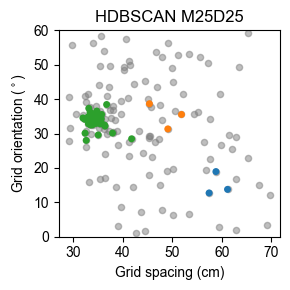

for module 0, there are 3 cells with average spacing 59.12650752692819
for module 1, there are 3 cells with average spacing 48.79472288460559
for module 2, there are 33 cells with average spacing 34.66376365589035
module 2 contains cells from ['VISp2/3' 'VISpl2/3' 'VISpl4' 'VISpl5']
module 1 contains cells from ['VISpl2/3' 'VISpl4' 'VISpl5']
module 0 contains cells from ['VISpl5']
25 25
for module 2, there are 33 cells
for module 1, there are 3 cells
for module 0, there are 3 cells
plotting vr rate maps using cluster_ids [2, 3, 14, 15, 69, 71, 76, 83, 87, 91, 96, 101, 104, 105, 106, 109, 110, 111, 112, 120, 207, 214, 215, 219, 227, 230, 231, 232, 233, 234, 235, 250, 264]


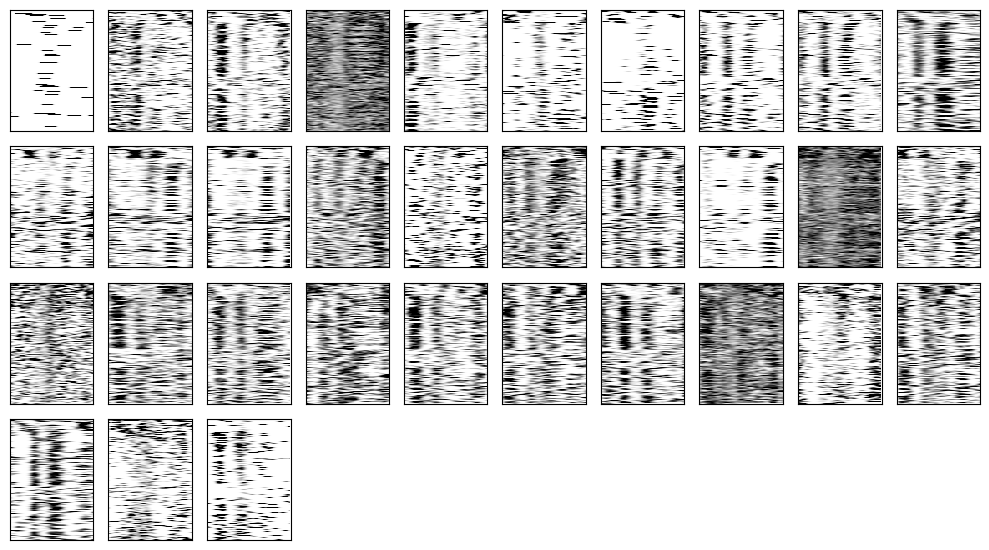

plotting vr rate maps using cluster_ids [11, 245, 293]


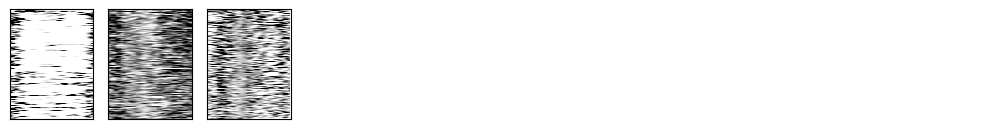

plotting vr rate maps using cluster_ids [169, 170, 209]


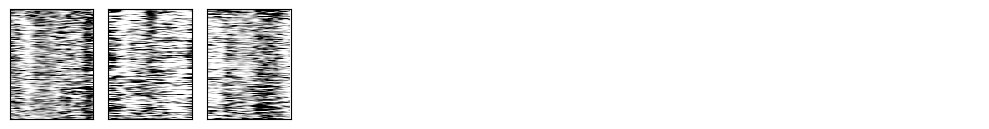

plotting vr rate maps using cluster_ids [1, 7, 13, 16, 17, 26, 32, 72, 73, 79, 80, 82, 85, 88, 89, 95, 97, 102, 117, 123, 127, 130, 133, 141, 148, 172, 173, 174, 175, 176, 177, 178, 179, 185, 186, 189, 191, 193, 196, 197, 198, 199, 202, 203, 204, 205, 206, 210, 217, 220, 221, 222, 225, 228, 229, 238, 240, 241, 242, 246, 249, 253, 262, 265, 273, 280, 281, 284, 285, 287, 297, 306, 307, 309, 310, 311, 312, 316]


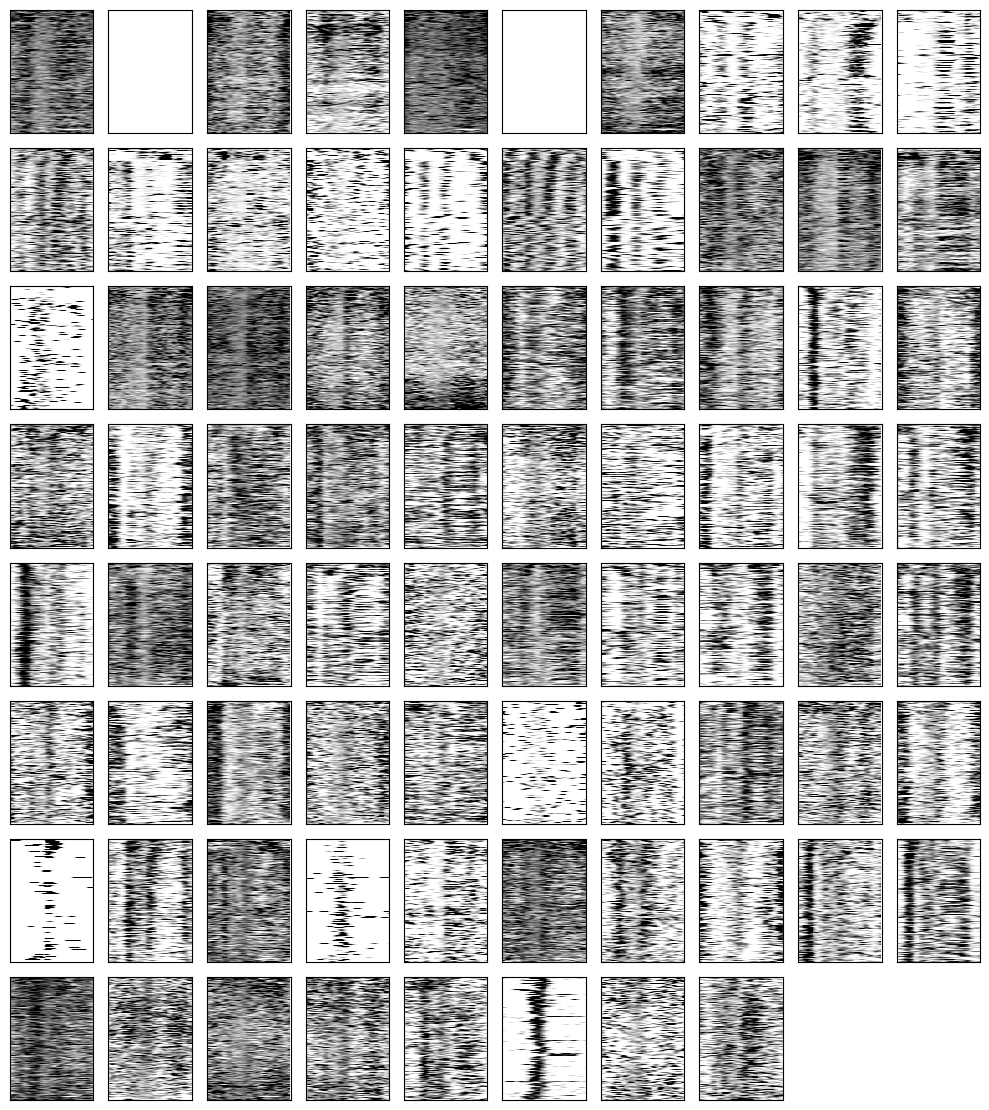

plotting vr rate maps using cluster_ids [8, 9, 60, 100, 108, 183, 201, 239, 247, 248, 254, 257, 291, 295]


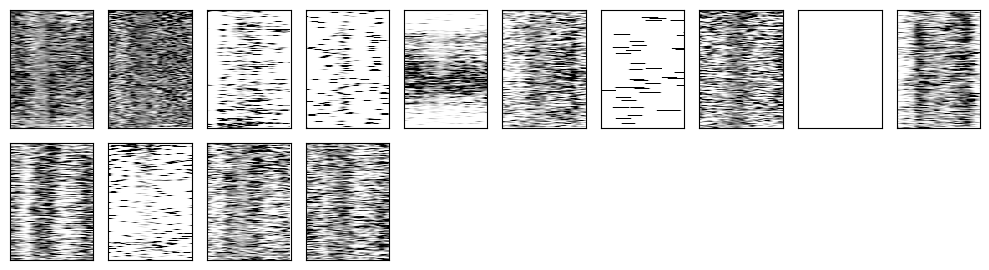

plotting vr rate maps using cluster_ids [2, 3, 11, 14, 15, 69, 71, 76, 83, 87, 91, 96, 101, 104, 105, 106, 109, 110, 111, 112, 120, 169, 170, 207, 209, 214, 215, 219, 227, 230, 231, 232, 233, 234, 235, 245, 250, 264, 293]


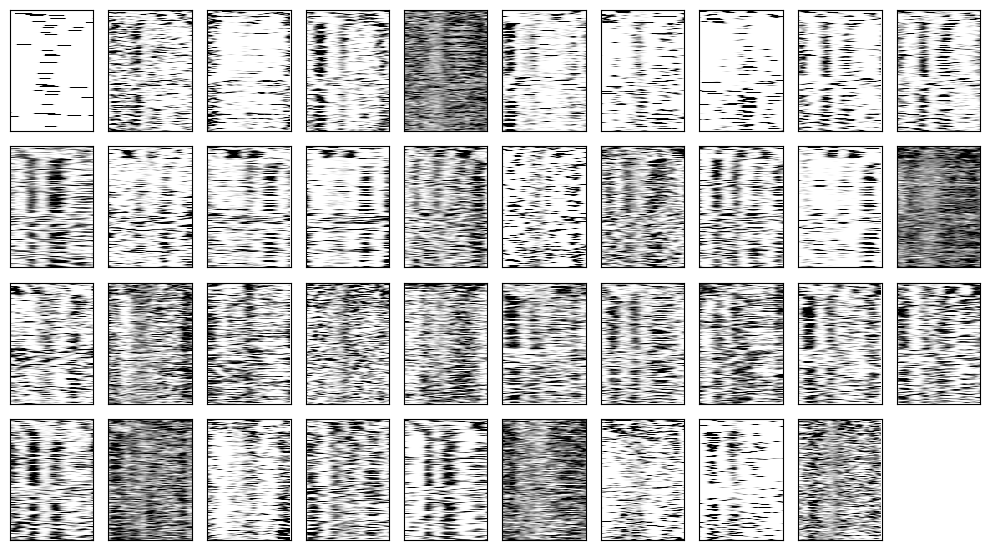

plotting vr rate maps using cluster_ids [10, 30, 31, 46, 90, 92, 138, 143, 149, 180, 181, 188, 211, 224, 252, 256, 283, 288, 303, 315, 322]


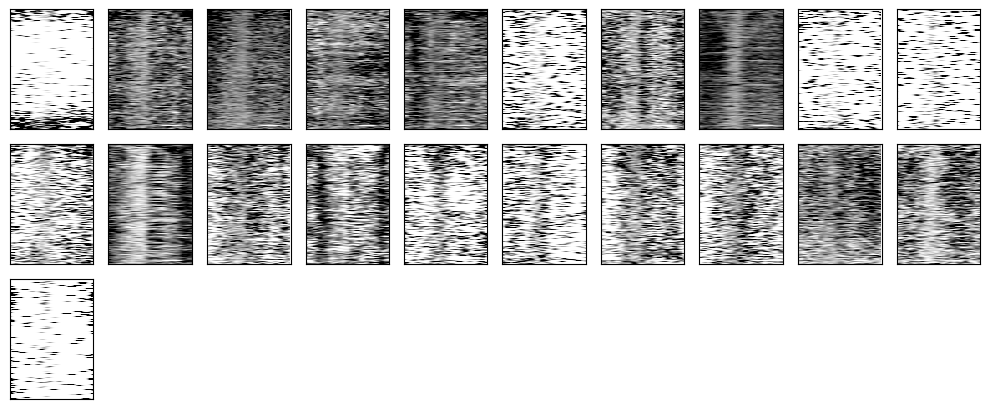

In [ ]:
gcs, ngs, ns, sc, ngs_ns, all = cell_classification_of1(mouse, day, percentile_threshold=95) # subset
rc, rsc, vr_ns = cell_classification_vr(mouse, day)
mec, para, pre, sub, vis, cere, other, all_by_anatomy = cell_classification_anatomy(mouse, day)
g_m_ids, g_m_cluster_ids = HDBSCAN_grid_modules(gcs, all, mouse, day, min_cluster_size=3, cluster_selection_epsilon=3, 
                                                figpath=fig_path, curate_with_vr=False, curate_with_brain_region=True, plot_curate=False) # create grid modules using HDBSCAN    

plot_grid_modules_rate_maps(gcs, g_m_ids, g_m_cluster_ids, mouse, day, figpath=fig_path)

# we now have cluster ids classified into modules, non grid spatial cells and non spatial cells 
# as defined by activity in the open field
g_m_cluster_ids = sorted(g_m_cluster_ids, key=len, reverse=True) 
cluster_ids_by_group = []
cluster_ids_by_group.extend(g_m_cluster_ids) # grid cells by module [0,1,2...]
cluster_ids_by_group.append(ngs.cluster_id.values.tolist()) # non grid spatial [-4]
cluster_ids_by_group.append(ns.cluster_id.values.tolist()) # non spatial cells [-3]
cluster_ids_by_group.append(gcs.cluster_id.values.tolist()) # all grid cells [-2]
cluster_ids_by_group.append(sc.cluster_id.values.tolist()) # speed cells [-1]

for m, cluster_ids in enumerate(cluster_ids_by_group):
    plot_vr_rate_maps(mouse, day, cluster_ids, label=f'{m}', figpath=fig_path)

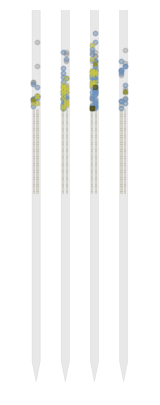

In [ ]:
markers = ['x', '^', 's']
fig, ax = plt.subplots(ncols=1, nrows=1, figsize=(4, 5), squeeze=False)
plot_NP2_probe(ax[0,0], sorting_analyzer_path='/Users/harryclark/Downloads/kilosort4_sa', contacts_alpha=0.3)
ax[0,0].scatter(all_by_anatomy['probe_x'], all_by_anatomy['probe_y'], color='tab:grey', alpha=0.3, s=10)
ax[0,0].scatter(ngs['probe_x'], ngs['probe_y'], color='#6897CD', alpha=0.3, s=10)
m_colors = ['#c04744', "#a36f3d", "#c0b244", "#3171ae", "#22220D"]
for m, cluster_ids in enumerate(g_m_cluster_ids):
    m_gcs = gcs[gcs.cluster_id.isin(cluster_ids)]
    ax[0,0].scatter(m_gcs['probe_x'], m_gcs['probe_y'], alpha=0.6, color=m_colors[m], marker=markers[m], s=10)
ax[0,0].set_xlim(-200, 1000)
ax[0,0].set_ylim(-300, 3000)
plt.savefig(f'/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_3_xgboost/M{mouse}D{day}_probe.pdf',  bbox_inches='tight')
plt.show()

In [5]:
tcs, tcs_time, _, last_ephys_bin, beh, clusters = compute_vr_tcs(mouse,day, apply_zscore=False, apply_guassian_filter=False)

last_ephys_time_bin = clusters[clusters.index[0]].count(bin_size=time_bs, time_units = 'ms').index[-1]

# time binned variables for later
ep = nap.IntervalSet(start=0, end=last_ephys_time_bin, time_units = 's')
speed_in_time = np.array(beh['S'].bin_average(bin_size=time_bs, time_units = 'ms', ep=ep))
dt_in_time = np.array(beh['travel'].bin_average(bin_size=time_bs, time_units = 'ms', ep=ep)-((beh['trial_number'][0]-1)*tl))
pos_in_time = dt_in_time%tl
trial_number_in_time = (dt_in_time//tl)+beh['trial_number'][0]

if np.any(np.isnan(pos_in_time)):
    series = pd.Series(dt_in_time)
    filled_series = series.ffill().bfill()
    dt_in_time = np.array(filled_series)
    pos_in_time = dt_in_time%tl
    trial_number_in_time = (dt_in_time//tl)+beh['trial_number'][0]

if np.any(np.isnan(speed_in_time)):
    series = pd.Series(speed_in_time)
    filled_series = series.ffill().bfill()
    speed_in_time = np.array(speed_in_time)

In [ ]:
cov_tcs_time_grids = {cluster_id: tcs_time[cluster_id] for cluster_id in gcs.cluster_id.values if cluster_id in tcs_time}
cov_tcs_time_ngs = {cluster_id: tcs_time[cluster_id] for cluster_id in ngs.cluster_id.values if cluster_id in tcs_time}

In [11]:
def circular_error(true_position, pred_position, tl=200):
    true_angles = (true_position/tl) * 2 * np.pi
    pred_angles = (pred_position/tl) * 2 * np.pi
    # Evaluate
    error_angle = np.min(np.stack([np.abs(pred_angles-true_angles),
                                   (2*np.pi)-np.abs(pred_angles-true_angles)]), axis=0)
    error_cm = (error_angle / (2 * np.pi)) * tl
    return error_cm

Sampling 1 cells, repeat 1/1
Sampling 5 cells, repeat 1/1
Sampling 10 cells, repeat 1/1
Sampling 15 cells, repeat 1/1
Sampling 20 cells, repeat 1/1
Sampling 25 cells, repeat 1/1
Sampling 30 cells, repeat 1/1


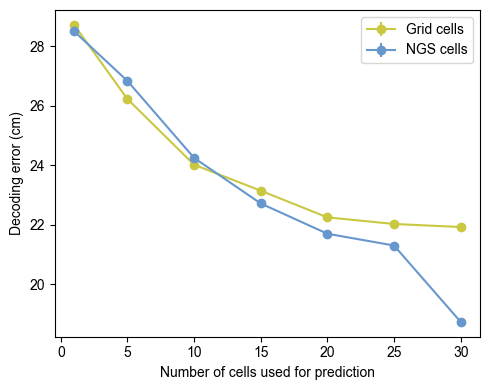

In [19]:
import numpy as np
import matplotlib.pyplot as plt

# Define the number of cells to sample for each test
n_cells_list = [1, 5, 10, 15, 20, 25, 30]  # adjust as needed

n_repeats = 1  # number of random samples per n_cells
results = {'grid': [], 'ngs': []}
predictions = {'grid': [], 'ngs': []}  # Store predictions for later plotting
errors = {'grid': [], 'ngs': []}  # Store errors for later plotting
for n_cells in n_cells_list:
    pr2_grid = []
    pr2_ngs = []
    errors_grid = []
    errors_ngs = []
    preds_grid = []
    preds_ngs = []
    for rep in range(n_repeats):
        print(f'Sampling {n_cells} cells, repeat {rep+1}/{n_repeats}')
        # --- Grid cells ---
        sampled_grid_ids = np.random.choice(gcs.cluster_id.values, n_cells, replace=False)
        X_grid = np.column_stack([tcs_time[cid] for cid in sampled_grid_ids if cid in tcs_time])
        y_pos = pos_in_time
        xgb_grid = MLencoding(tunemodel='xgboost', cov_history=True, spike_history=False, window=time_bs, n_filters=5, max_time=1000)
        Y_hat_grid, pR2_cv_grid = xgb_grid.fit_cv(X_grid, y_pos, verbose=0, continuous_folds=True)
        pr2_grid.append(np.nanmean(pR2_cv_grid))
        errors_grid.append(circular_error(y_pos, Y_hat_grid, tl=tl).mean())
        preds_grid.append(Y_hat_grid)
        # --- NGS cells ---
        if len(ngs.cluster_id.values) >= n_cells:
            sampled_ngs_ids = np.random.choice(ngs.cluster_id.values, n_cells, replace=False)
            X_ngs = np.column_stack([tcs_time[cid] for cid in sampled_ngs_ids if cid in tcs_time])
            xgb_ngs = MLencoding(tunemodel='xgboost', cov_history=True, spike_history=False, window=time_bs, n_filters=5, max_time=1000)
            Y_hat_ngs, pR2_cv_ngs = xgb_ngs.fit_cv(X_ngs, y_pos, verbose=0, continuous_folds=True)
            pr2_ngs.append(np.nanmean(pR2_cv_ngs))
            errors_ngs.append(circular_error(y_pos, Y_hat_ngs, tl=tl).mean())
            preds_ngs.append(Y_hat_ngs)
        else:
            pr2_ngs.append(np.nan)
            errors_ngs.append(np.nan)
            preds_ngs.append(np.full_like(y_pos, np.nan))

    results['grid'].append(pr2_grid)
    results['ngs'].append(pr2_ngs)
    errors['grid'].append(errors_grid)
    errors['ngs'].append(errors_ngs)
    predictions['grid'].append(preds_grid)
    predictions['ngs'].append(preds_ngs)

# Convert to arrays for plotting
mean_grid = np.nanmean(errors['grid'], axis=1)
sem_grid = np.nanstd(errors['grid'], axis=1) / np.sqrt(n_repeats)
mean_ngs = np.nanmean(errors['ngs'], axis=1)
sem_ngs = np.nanstd(errors['ngs'], axis=1) / np.sqrt(n_repeats)

plt.figure(figsize=(5, 4))
plt.errorbar(n_cells_list, mean_grid, yerr=sem_grid, label='Grid cells', color='#CAC841', marker='o')
plt.errorbar(n_cells_list, mean_ngs, yerr=sem_ngs, label='NGS cells', color='#6897CD', marker='o')
plt.xlabel('Number of cells used for prediction')
plt.ylabel('Decoding error (cm)')
plt.legend()
plt.tight_layout()
plt.savefig(f'/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_3_xgboost/M{mouse}D{day}_position_prediction_vs_ncells.pdf', bbox_inches='tight')
plt.show()



# Example: plot predictions for the first repeat and first n_cells for grid cells
# plt.plot(pos_in_time, label='True position')
# plt.plot(predictions['grid'][0][0], label='Predicted (grid, n_cells=1, rep=1)')
# plt.legend()
# plt.show()

In [20]:
figpath_rm = '/Users/harryclark/Desktop/M25D25/'
plot_individual_rate_maps_with_avg_by_trial_type(mouse, day, cluster_ids=gcs.cluster_id.values, label='GC', figpath=figpath_rm)
plot_individual_rate_maps_with_avg_by_trial_type(mouse, day, cluster_ids=ngs.cluster_id.values, label='NGS', figpath=figpath_rm)

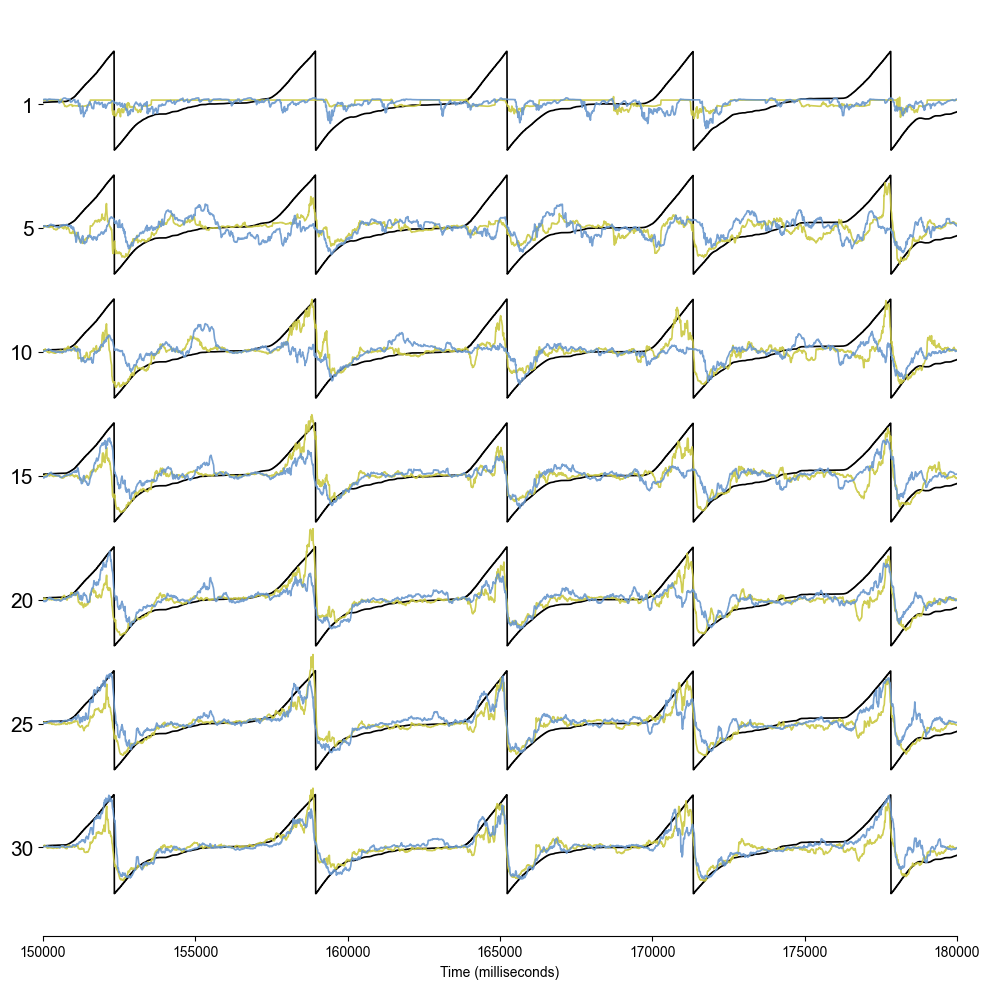

: 

In [ ]:
# Overlay: For each n_cells, overlay grid and NGS predictions on top of true, stacked from top (n=1) to bottom (n=30)

n_cells_to_plot = n_cells_list  # [1, 5, 10, 15, 20, 25, 30]
colors = {'grid': '#CAC841', 'ngs': '#6897CD', 'true': 'black'}
labels = {'grid': 'Grid', 'ngs': 'NGS', 'true': 'True'}
offset = 250  # vertical offset between traces (in cm), increased for more space
start = 15000
end = 18000

fig, ax = plt.subplots(figsize=(10, 10))
sf = 1  # scale factor for the y-axis

yticks = []
yticklabels = []

for i, n_cells in enumerate(n_cells_to_plot):
    idx = n_cells_list.index(n_cells)
    y_base = offset * (len(n_cells_to_plot) - 1 - i)
    # True position (PLOT FIRST, SO IT'S UNDER)
    ax.plot(np.arange(len(pos_in_time))[start:end]*time_bs, pos_in_time[start:end]*sf + y_base,
            color=colors['true'], linewidth=1.2, label='True' if i == 0 else None, zorder=1)
    # Grid prediction (PLOT SECOND, ON TOP)
    grid_pred = predictions['grid'][idx][0]
    ax.plot(np.arange(len(pos_in_time))[start:end]*time_bs, grid_pred[start:end]*sf + y_base,
            color=colors['grid'], linewidth=1.2, label='Grid' if i == 0 else None, alpha=0.9, zorder=2)
    # NGS prediction (PLOT THIRD, ON TOP)
    ngs_pred = predictions['ngs'][idx][0]
    if not np.all(np.isnan(ngs_pred)):
        ax.plot(np.arange(len(pos_in_time))[start:end]*time_bs, ngs_pred[start:end]*sf + y_base,
                color=colors['ngs'], linewidth=1.2, label='NGS' if i == 0 else None, alpha=0.9, zorder=3)
    # y-ticks
    yticks.append(y_base + np.mean(pos_in_time[start:end]*sf))
    yticklabels.append(f'{n_cells}')

ax.set_yticks(yticks)
ax.set_yticklabels(yticklabels, fontsize=15)
ax.set_xlabel('Time (milliseconds)')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.set_xlim(start*time_bs, end*time_bs)
plt.tight_layout()
plt.savefig(f'/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_3_xgboost/M{mouse}D{day}_overlay_true_vs_pred_all_ncells_overlay.pdf', bbox_inches='tight', dpi=500)
plt.show()

In [25]:
pos_in_time.shape

(180726,)

plot a grid cell

In [ ]:
print('plot a grid cell')
fig, ax = plt.subplots(ncols=1, nrows=1, figsize=(2, 2), squeeze=False)
plot_firing_rate_map(ax[0,0], zscore(tcs[gcs.cluster_id.values[9]]), bs=bs, tl=tl, p=95)
plt.show()
print('plot a grid cell')
fig, ax = plt.subplots(ncols=1, nrows=1, figsize=(2, 2), squeeze=False)
plot_firing_rate_map(ax[0,0], zscore(tcs[gcs.cluster_id.values[10]]), bs=bs, tl=tl, p=95)
plt.show()
print('plot a ngs cell')
fig, ax = plt.subplots(ncols=1, nrows=1, figsize=(2, 2), squeeze=False)
plot_firing_rate_map(ax[0,0], zscore(tcs[ngs.cluster_id.values[2]]), bs=bs, tl=tl, p=95)
plt.show()

In [ ]:
gcs_minus_test = gcs[gcs.cluster_id != gcs.cluster_id.values[9]]
cov_tcs_time_grids = {cluster_id: tcs_time[cluster_id] for cluster_id in gcs_minus_test.cluster_id.values if cluster_id in tcs_time}
cov_tcs_time_ngs = {cluster_id: tcs_time[cluster_id] for cluster_id in ngs.cluster_id.values if cluster_id in tcs_time}
cov_tcs_time_cere = {cluster_id: tcs_time[cluster_id] for cluster_id in cere.cluster_id.values if cluster_id in tcs_time}

In [ ]:
xgb_history = MLencoding(tunemodel = 'xgboost',
                         cov_history = True, spike_history=False, # We can choose!
                         window = time_bs, #this dataset has 100ms time bins
                         n_filters = 5,
                         max_time = 1000)

y = np.array(tcs_time[gcs.cluster_id.values[9]])
X  = np.stack([pos_in_time]).T # pos in time

Xg1 = np.stack([np.array(tcs_time[gcs.cluster_id.values[10]])]).T # grid cell 10
Xngs1 = np.stack([np.array(tcs_time[ngs.cluster_id.values[2]])]).T # ngs cell 2
Xcere1 = np.stack([np.array(tcs_time[cere.cluster_id.values[0]])]).T # cerebellar cell 0

Xgmax = np.column_stack((np.vstack(list(cov_tcs_time_grids.values())).T)).T # grid cells         
Xngsmax = np.column_stack((np.vstack(list(cov_tcs_time_ngs.values())).T)).T # non grid spatial cells        
Xceremax = np.column_stack((np.vstack(list(cov_tcs_time_cere.values())).T)).T # cerebellar cells        

Xpos_g1 = np.stack([pos_in_time, np.array(tcs_time[gcs.cluster_id.values[10]])]).T # grid cell 10 + pos in time
Xpos_ngs1 = np.stack([pos_in_time, np.array(tcs_time[ngs.cluster_id.values[2]])]).T # ngs cell 2 + pos in time
Xpos_cere1 = np.stack([pos_in_time, np.array(tcs_time[cere.cluster_id.values[0]])]).T  # cerebellar cell 0 + pos in time

Xpos_gmax = np.column_stack((pos_in_time, np.vstack(list(cov_tcs_time_grids.values())).T)) # grid cells + pos in time     
Xpos_ngsmax = np.column_stack((pos_in_time, np.vstack(list(cov_tcs_time_ngs.values())).T)) # non grid spatial cells + pos in time      
Xpos_ceremax = np.column_stack((pos_in_time, np.vstack(list(cov_tcs_time_cere.values())).T)) # cerebellar cells + pos in time       


Y_hat_p, pR2_cv_p = xgb_history.fit_cv(X, y, verbose = 0, continuous_folds = True)

Y_hat_g1, pR2_cv_g1 = xgb_history.fit_cv(Xg1, y, verbose = 0, continuous_folds = True)
Y_hat_ngs1, pR2_cv_ngs1 = xgb_history.fit_cv(Xngs1, y, verbose = 0, continuous_folds = True)
Y_hat_cere1, pR2_cv_cere1 = xgb_history.fit_cv(Xcere1, y, verbose = 0, continuous_folds = True)

Y_hat_gmax, pR2_cv_gmax = xgb_history.fit_cv(Xgmax, y, verbose = 0, continuous_folds = True)
Y_hat_ngsmax, pR2_cv_ngsmax = xgb_history.fit_cv(Xngsmax, y, verbose = 0, continuous_folds = True)
Y_hat_ceremax, pR2_cv_ceremax = xgb_history.fit_cv(Xceremax, y, verbose = 0, continuous_folds = True)   

Y_hat_pos_g1, pR2_cv_pos_g1 = xgb_history.fit_cv(Xpos_g1, y, verbose = 0, continuous_folds = True)
Y_hat_pos_ngs1, pR2_cv_pos_ngs1 = xgb_history.fit_cv(Xpos_ngs1, y, verbose = 0, continuous_folds = True)
Y_hat_pos_cere1, pR2_cv_pos_cere1 = xgb_history.fit_cv(Xpos_cere1, y, verbose = 0, continuous_folds = True)

Y_hat_pos_gmax, pR2_cv_pos_gmax = xgb_history.fit_cv(Xpos_gmax, y, verbose = 0, continuous_folds = True)
Y_hat_pos_ngsmax, pR2_cv_pos_ngsmax = xgb_history.fit_cv(Xpos_ngsmax, y, verbose = 0, continuous_folds = True)
Y_hat_pos_ceremax, pR2_cv_pos_ceremax = xgb_history.fit_cv(Xpos_ceremax, y, verbose = 0, continuous_folds = True)  

In [ ]:
offset = 2  # vertical offset between traces

fig, ax = plt.subplots(figsize=(5, 5))
start=0
end=1000
sf = -2 # scale factor for the y-axis
lw = 0.75
ax.plot(np.arange(len(y))[start:end]*time_bs, y[start:end]*sf, label='True', color='black', linewidth=lw)
ax.plot(np.arange(len(Y_hat_p))[start:end]*time_bs, Y_hat_p[start:end]*sf + offset, color='tab:orange', linewidth=lw, label='Position')
ax.plot(np.arange(len(Y_hat_g1))[start:end]*time_bs, Y_hat_g1[start:end]*sf + (offset*2), color='#CAC841', linewidth=lw, label='Grid cell 10')
ax.plot(np.arange(len(Y_hat_ngs1))[start:end]*time_bs, Y_hat_ngs1[start:end]*sf + (offset*3), color='#6897CD', linewidth=lw, label='NGS cell 2')
ax.plot(np.arange(len(Y_hat_cere1))[start:end]*time_bs, Y_hat_cere1[start:end]*sf + (offset*4), color='#DAB978', linewidth=lw, label='Cerebellar cell 0')
ax.plot(np.arange(len(Y_hat_gmax))[start:end]*time_bs, Y_hat_gmax[start:end]*sf + (offset*5), color='#CAC841', linewidth=lw, label='Grid cells')
ax.plot(np.arange(len(Y_hat_ngsmax))[start:end]*time_bs, Y_hat_ngsmax[start:end]*sf + (offset*6), color='#6897CD', linewidth=lw, label='NGS cells')
ax.plot(np.arange(len(Y_hat_ceremax))[start:end]*time_bs, Y_hat_ceremax[start:end]*sf + (offset*7), color='#DAB978', linewidth=lw, label='Cerebellar cells')   
ax.plot(np.arange(len(Y_hat_pos_g1))[start:end]*time_bs, Y_hat_pos_g1[start:end]*sf + (offset*8), color='#CAC841', linewidth=lw, linestyle='--', label='Position + Grid cell 10')
ax.plot(np.arange(len(Y_hat_pos_ngs1))[start:end]*time_bs, Y_hat_pos_ngs1[start:end]*sf + (offset*9), color='#6897CD', linewidth=lw, linestyle='--', label='Position + NGS cell 2')
ax.plot(np.arange(len(Y_hat_pos_cere1))[start:end]*time_bs, Y_hat_pos_cere1[start:end]*sf + (offset*10), color='#DAB978', linewidth=lw, linestyle='--', label='Position + Cerebellar cell 0')
ax.plot(np.arange(len(Y_hat_pos_gmax))[start:end]*time_bs, Y_hat_pos_gmax[start:end]*sf + (offset*11), color='#CAC841', linewidth=lw, linestyle='--', label='Position + Grid cells')
ax.plot(np.arange(len(Y_hat_pos_ngsmax))[start:end]*time_bs, Y_hat_pos_ngsmax[start:end]*sf + (offset*12), color='#6897CD', linewidth=lw, linestyle='--', label='Position + NGS cells')
ax.plot(np.arange(len(Y_hat_pos_ceremax))[start:end]*time_bs, Y_hat_pos_ceremax[start:end]*sf + (offset*13), color='#DAB978', linewidth=lw, linestyle='--', label='Position + Cerebellar cells')
ax.set_xlabel('Time (millseconds)')

# Annotate mean pR² values with superscript
ax.text(end*time_bs + 10, np.mean(y[start:end]*sf), 'True', va='center', fontsize=8, color='black')
ax.text(end*time_bs + 10, np.mean(Y_hat_p[start:end]*sf + offset), f'pR$^2$={np.nanmean(pR2_cv_p):.2f}', va='center', fontsize=8, color='tab:orange')
ax.text(end*time_bs + 10, np.mean(Y_hat_g1[start:end]*sf + (offset*2)), f'pR$^2$={np.nanmean(pR2_cv_g1):.2f}', va='center', fontsize=8, color='#CAC841')
ax.text(end*time_bs + 10, np.mean(Y_hat_ngs1[start:end]*sf + (offset*3)), f'pR$^2$={np.nanmean(pR2_cv_ngs1):.2f}', va='center', fontsize=8, color='#6897CD')
ax.text(end*time_bs + 10, np.mean(Y_hat_cere1[start:end]*sf + (offset*4)), f'pR$^2$={np.nanmean(pR2_cv_cere1):.2f}', va='center', fontsize=8, color='#DAB978')
ax.text(end*time_bs + 10, np.mean(Y_hat_gmax[start:end]*sf + (offset*5)), f'pR$^2$={np.nanmean(pR2_cv_gmax):.2f}', va='center', fontsize=8, color='#CAC841')
ax.text(end*time_bs + 10, np.mean(Y_hat_ngsmax[start:end]*sf + (offset*6)), f'pR$^2$={np.nanmean(pR2_cv_ngsmax):.2f}', va='center', fontsize=8, color='#6897CD')
ax.text(end*time_bs + 10, np.mean(Y_hat_ceremax[start:end]*sf + (offset*7)), f'pR$^2$={np.nanmean(pR2_cv_ceremax):.2f}', va='center', fontsize=8, color='#DAB978')
ax.text(end*time_bs + 10, np.mean(Y_hat_pos_g1[start:end]*sf + (offset*8)), f'pR$^2$={np.nanmean(pR2_cv_pos_g1):.2f}', va='center', fontsize=8, color='#CAC841')
ax.text(end*time_bs + 10, np.mean(Y_hat_pos_ngs1[start:end]*sf + (offset*9)), f'pR$^2$={np.nanmean(pR2_cv_pos_ngs1):.2f}', va='center', fontsize=8, color='#6897CD')
ax.text(end*time_bs + 10, np.mean(Y_hat_pos_cere1[start:end]*sf + (offset*10)), f'pR$^2$={np.nanmean(pR2_cv_pos_cere1):.2f}', va='center', fontsize=8, color='#DAB978')
ax.text(end*time_bs + 10, np.mean(Y_hat_pos_gmax[start:end]*sf + (offset*11)), f'pR$^2$={np.nanmean(pR2_cv_pos_gmax):.2f}', va='center', fontsize=8, color='#CAC841')
ax.text(end*time_bs + 10, np.mean(Y_hat_pos_ngsmax[start:end]*sf + (offset*12)), f'pR$^2$={np.nanmean(pR2_cv_pos_ngsmax):.2f}', va='center', fontsize=8, color='#6897CD')
ax.text(end*time_bs + 10, np.mean(Y_hat_pos_ceremax[start:end]*sf + (offset*13)), f'pR$^2$={np.nanmean(pR2_cv_pos_ceremax):.2f}', va='center', fontsize=8, color='#DAB978')

#ax.legend()
# remove top, left and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.set_yticklabels([])
ax.set_yticks([])
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(f'/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_3_xgboost/xgboost_example_trained_on_grid_cell_9_mouse{mouse}_day{day}.pdf', bbox_inches='tight')
plt.show()


We can use different trial conditions of task-anchored labels to assess the difference of predictive accuracy in different parts of the session. Here we use task-anchored labels are plot the predictivity across groups

In [ ]:
labels_in_time = get_task_anchored_labels_in_time(mouse,day,cluster_ids_for_spectrogram=g_m_cluster_ids[0])

offset = 2  # vertical offset between traces
start=2000
end=3000
sf = -2 # scale factor for the y-axis
lw = 0.75
for label in np.unique(labels_in_time):
    print(f'Plotting label {label}')
    fig, ax = plt.subplots(figsize=(5, 5))
    ax.plot(np.arange(len(y[labels_in_time==label]))[start:end]*time_bs, y[labels_in_time==label][start:end]*sf, label='True', color='black', linewidth=lw)
    ax.plot(np.arange(len(Y_hat_p[labels_in_time==label]))[start:end]*time_bs, Y_hat_p[labels_in_time==label][start:end]*sf + offset, color='tab:orange', linewidth=lw, label='Position')
    ax.plot(np.arange(len(Y_hat_g1[labels_in_time==label]))[start:end]*time_bs, Y_hat_g1[labels_in_time==label][start:end]*sf + (offset*2), color='#CAC841', linewidth=lw, label='Grid cell 10')
    ax.plot(np.arange(len(Y_hat_ngs1[labels_in_time==label]))[start:end]*time_bs, Y_hat_ngs1[labels_in_time==label][start:end]*sf + (offset*3), color='#6897CD', linewidth=lw, label='NGS cell 2')
    ax.plot(np.arange(len(Y_hat_cere1[labels_in_time==label]))[start:end]*time_bs, Y_hat_cere1[labels_in_time==label][start:end]*sf + (offset*4), color='#DAB978', linewidth=lw, label='Cerebellar cell 0')
    ax.plot(np.arange(len(Y_hat_gmax[labels_in_time==label]))[start:end]*time_bs, Y_hat_gmax[labels_in_time==label][start:end]*sf + (offset*5), color='#CAC841', linewidth=lw, label='Grid cells')
    ax.plot(np.arange(len(Y_hat_ngsmax[labels_in_time==label]))[start:end]*time_bs, Y_hat_ngsmax[labels_in_time==label][start:end]*sf + (offset*6), color='#6897CD', linewidth=lw, label='NGS cells')
    ax.plot(np.arange(len(Y_hat_ceremax[labels_in_time==label]))[start:end]*time_bs, Y_hat_ceremax[labels_in_time==label][start:end]*sf + (offset*7), color='#DAB978', linewidth=lw, label='Cerebellar cells')   
    ax.plot(np.arange(len(Y_hat_pos_g1[labels_in_time==label]))[start:end]*time_bs, Y_hat_pos_g1[labels_in_time==label][start:end]*sf + (offset*8), color='#CAC841', linewidth=lw, linestyle='--', label='Position + Grid cell 10')
    ax.plot(np.arange(len(Y_hat_pos_ngs1[labels_in_time==label]))[start:end]*time_bs, Y_hat_pos_ngs1[labels_in_time==label][start:end]*sf + (offset*9), color='#6897CD', linewidth=lw, linestyle='--', label='Position + NGS cell 2')
    ax.plot(np.arange(len(Y_hat_pos_cere1[labels_in_time==label]))[start:end]*time_bs, Y_hat_pos_cere1[labels_in_time==label][start:end]*sf + (offset*10), color='#DAB978', linewidth=lw, linestyle='--', label='Position + Cerebellar cell 0')
    ax.plot(np.arange(len(Y_hat_pos_gmax[labels_in_time==label]))[start:end]*time_bs, Y_hat_pos_gmax[labels_in_time==label][start:end]*sf + (offset*11), color='#CAC841', linewidth=lw, linestyle='--', label='Position + Grid cells')
    ax.plot(np.arange(len(Y_hat_pos_ngsmax[labels_in_time==label]))[start:end]*time_bs, Y_hat_pos_ngsmax[labels_in_time==label][start:end]*sf + (offset*12), color='#6897CD', linewidth=lw, linestyle='--', label='Position + NGS cells')
    ax.plot(np.arange(len(Y_hat_pos_ceremax[labels_in_time==label]))[start:end]*time_bs, Y_hat_pos_ceremax[labels_in_time==label][start:end]*sf + (offset*13), color='#DAB978', linewidth=lw, linestyle='--', label='Position + Cerebellar cells')
    ax.set_xlabel('Time (millseconds)')

    # Annotate mean pR² values with superscript
    ax.text(end*time_bs + 10, np.mean(y[labels_in_time==label][start:end]*sf), 'True', va='center', fontsize=8, color='black')
    ax.text(end*time_bs + 10, np.mean(Y_hat_p[labels_in_time==label][start:end]*sf + offset), f'pR$^2$={poisson_pseudoR2(y[labels_in_time==label], Y_hat_p[labels_in_time==label], np.mean(y[labels_in_time==label])):.2f}', va='center', fontsize=8, color='tab:orange')
    ax.text(end*time_bs + 10, np.mean(Y_hat_g1[labels_in_time==label][start:end]*sf + (offset*2)), f'pR$^2$={poisson_pseudoR2(y[labels_in_time==label], Y_hat_g1[labels_in_time==label], np.mean(y[labels_in_time==label])):.2f}', va='center', fontsize=8, color='#CAC841')
    ax.text(end*time_bs + 10, np.mean(Y_hat_ngs1[labels_in_time==label][start:end]*sf + (offset*3)), f'pR$^2$={poisson_pseudoR2(y[labels_in_time==label], Y_hat_ngs1[labels_in_time==label], np.mean(y[labels_in_time==label])):.2f}', va='center', fontsize=8, color='#6897CD')
    ax.text(end*time_bs + 10, np.mean(Y_hat_cere1[labels_in_time==label][start:end]*sf + (offset*4)), f'pR$^2$={poisson_pseudoR2(y[labels_in_time==label], Y_hat_cere1[labels_in_time==label], np.mean(y[labels_in_time==label])):.2f}', va='center', fontsize=8, color='#DAB978')
    ax.text(end*time_bs + 10, np.mean(Y_hat_gmax[labels_in_time==label][start:end]*sf + (offset*5)), f'pR$^2$={poisson_pseudoR2(y[labels_in_time==label], Y_hat_gmax[labels_in_time==label], np.mean(y[labels_in_time==label])):.2f}', va='center', fontsize=8, color='#CAC841')
    ax.text(end*time_bs + 10, np.mean(Y_hat_ngsmax[labels_in_time==label][start:end]*sf + (offset*6)), f'pR$^2$={poisson_pseudoR2(y[labels_in_time==label], Y_hat_ngsmax[labels_in_time==label], np.mean(y[labels_in_time==label])):.2f}', va='center', fontsize=8, color='#6897CD')
    ax.text(end*time_bs + 10, np.mean(Y_hat_ceremax[labels_in_time==label][start:end]*sf + (offset*7)), f'pR$^2$={poisson_pseudoR2(y[labels_in_time==label], Y_hat_ceremax[labels_in_time==label], np.mean(y[labels_in_time==label])):.2f}', va='center', fontsize=8, color='#DAB978')
    ax.text(end*time_bs + 10, np.mean(Y_hat_pos_g1[labels_in_time==label][start:end]*sf + (offset*8)), f'pR$^2$={poisson_pseudoR2(y[labels_in_time==label], Y_hat_pos_g1[labels_in_time==label], np.mean(y[labels_in_time==label])):.2f}', va='center', fontsize=8, color='#CAC841')
    ax.text(end*time_bs + 10, np.mean(Y_hat_pos_ngs1[labels_in_time==label][start:end]*sf + (offset*9)), f'pR$^2$={poisson_pseudoR2(y[labels_in_time==label], Y_hat_pos_ngs1[labels_in_time==label], np.mean(y[labels_in_time==label])):.2f}', va='center', fontsize=8, color='#6897CD')
    ax.text(end*time_bs + 10, np.mean(Y_hat_pos_cere1[labels_in_time==label][start:end]*sf + (offset*10)), f'pR$^2$={poisson_pseudoR2(y[labels_in_time==label], Y_hat_pos_cere1[labels_in_time==label], np.mean(y[labels_in_time==label])):.2f}', va='center', fontsize=8, color='#DAB978')
    ax.text(end*time_bs + 10, np.mean(Y_hat_pos_gmax[labels_in_time==label][start:end]*sf + (offset*11)), f'pR$^2$={poisson_pseudoR2(y[labels_in_time==label], Y_hat_pos_gmax[labels_in_time==label], np.mean(y[labels_in_time==label])):.2f}', va='center', fontsize=8, color='#CAC841')
    ax.text(end*time_bs + 10, np.mean(Y_hat_pos_ngsmax[labels_in_time==label][start:end]*sf + (offset*12)), f'pR$^2$={poisson_pseudoR2(y[labels_in_time==label], Y_hat_pos_ngsmax[labels_in_time==label], np.mean(y[labels_in_time==label])):.2f}', va='center', fontsize=8, color='#6897CD')
    ax.text(end*time_bs + 10, np.mean(Y_hat_pos_ceremax[labels_in_time==label][start:end]*sf + (offset*13)), f'pR$^2$={poisson_pseudoR2(y[labels_in_time==label], Y_hat_pos_ceremax[labels_in_time==label], np.mean(y[labels_in_time==label])):.2f}', va='center', fontsize=8, color='#DAB978') 
    #ax.legend()
    # remove top, left and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.set_yticklabels([])
    ax.set_yticks([])
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()



we can see that various combinations of covariates can predict the grid cell activity to various degrees 

Now we will visual the effect of the history parameter


In [ ]:
xgb_history = [MLencoding(tunemodel = 'xgboost',
                         cov_history = True, spike_history=False, # We can choose!
                         window = time_bs, #this dataset has 100ms time bins
                         n_filters = 5,
                         max_time = x) for x in [50, 100, 200, 300, 400, 500, 600, 700, 800, 900, 1000]]
y = np.array(tcs_time[gcs.cluster_id.values[9]])
X = Xg1.copy() # grid cell 10

Y_hat_g1_h1, pR2_cv_g1_h1 = xgb_history[0].fit_cv(X, y, verbose = 0, continuous_folds = True)
Y_hat_g1_h2, pR2_cv_g1_h2 = xgb_history[1].fit_cv(X, y, verbose = 0, continuous_folds = True)
Y_hat_g1_h3, pR2_cv_g1_h3 = xgb_history[2].fit_cv(X, y, verbose = 0, continuous_folds = True)
Y_hat_g1_h4, pR2_cv_g1_h4 = xgb_history[3].fit_cv(X, y, verbose = 0, continuous_folds = True)
Y_hat_g1_h5, pR2_cv_g1_h5 = xgb_history[4].fit_cv(X, y, verbose = 0, continuous_folds = True)
Y_hat_g1_h6, pR2_cv_g1_h6 = xgb_history[5].fit_cv(X, y, verbose = 0, continuous_folds = True)
Y_hat_g1_h7, pR2_cv_g1_h7 = xgb_history[6].fit_cv(X, y, verbose = 0, continuous_folds = True)
Y_hat_g1_h8, pR2_cv_g1_h8 = xgb_history[7].fit_cv(X, y, verbose = 0, continuous_folds = True)
Y_hat_g1_h9, pR2_cv_g1_h9 = xgb_history[8].fit_cv(X, y, verbose = 0, continuous_folds = True)
Y_hat_g1_h10, pR2_cv_g1_h10 = xgb_history[9].fit_cv(X, y, verbose = 0, continuous_folds = True)
Y_hat_g1_h11, pR2_cv_g1_h11 = xgb_history[10].fit_cv(X, y, verbose = 0, continuous_folds = True)

offset = 2  # vertical offset between traces

fig, ax = plt.subplots(figsize=(5, 5))
start=0
end=1000
sf = -2 # scale factor for the y-axis
lw = 0.75
ax.plot(np.arange(len(y))[start:end]*time_bs, y[start:end]*sf, label='True', color='black', linewidth=lw)
ax.plot(np.arange(len(Y_hat_g1_h1))[start:end]*time_bs, Y_hat_g1_h1[start:end]*sf + offset, color='#CAC841', linewidth=lw, label='history 1')
ax.plot(np.arange(len(Y_hat_g1_h2))[start:end]*time_bs, Y_hat_g1_h2[start:end]*sf + (offset*2), color='#CAC841', linewidth=lw, label='history 2')
ax.plot(np.arange(len(Y_hat_g1_h3))[start:end]*time_bs, Y_hat_g1_h3[start:end]*sf + (offset*3), color='#CAC841', linewidth=lw, label='history 3')
ax.plot(np.arange(len(Y_hat_g1_h4))[start:end]*time_bs, Y_hat_g1_h4[start:end]*sf + (offset*4), color='#CAC841', linewidth=lw, label='history 4')
ax.plot(np.arange(len(Y_hat_g1_h5))[start:end]*time_bs, Y_hat_g1_h5[start:end]*sf + (offset*5), color='#CAC841', linewidth=lw, label='history 5')
ax.plot(np.arange(len(Y_hat_g1_h6))[start:end]*time_bs, Y_hat_g1_h6[start:end]*sf + (offset*6), color='#CAC841', linewidth=lw, label='history 6')
ax.plot(np.arange(len(Y_hat_g1_h7))[start:end]*time_bs, Y_hat_g1_h7[start:end]*sf + (offset*7), color='#CAC841', linewidth=lw, label='history 7')
ax.plot(np.arange(len(Y_hat_g1_h8))[start:end]*time_bs, Y_hat_g1_h8[start:end]*sf + (offset*8), color='#CAC841', linewidth=lw, label='history 8')
ax.plot(np.arange(len(Y_hat_g1_h9))[start:end]*time_bs, Y_hat_g1_h9[start:end]*sf + (offset*9), color='#CAC841', linewidth=lw, label='history 9')
ax.plot(np.arange(len(Y_hat_g1_h10))[start:end]*time_bs, Y_hat_g1_h10[start:end]*sf + (offset*10), color='#CAC841', linewidth=lw, label='history 10')
ax.plot(np.arange(len(Y_hat_g1_h11))[start:end]*time_bs, Y_hat_g1_h11[start:end]*sf + (offset*11), color='#CAC841', linewidth=lw, label='history 11')

ax.set_xlabel('Time (millseconds)')

# Annotate mean pR² values with superscript
ax.text(end*time_bs + 10, np.mean(y[start:end]*sf), 'True', va='center', fontsize=8, color='black')
ax.text(end*time_bs + 10, np.mean(Y_hat_g1_h1[start:end]*sf + offset), f'pR$^2$={np.nanmean(pR2_cv_g1_h1):.2f}', va='center', fontsize=8, color='#CAC841')
ax.text(end*time_bs + 10, np.mean(Y_hat_g1_h2[start:end]*sf + (offset*2)), f'pR$^2$={np.nanmean(pR2_cv_g1_h2):.2f}', va='center', fontsize=8, color='#CAC841')
ax.text(end*time_bs + 10, np.mean(Y_hat_g1_h3[start:end]*sf + (offset*3)), f'pR$^2$={np.nanmean(pR2_cv_g1_h3):.2f}', va='center', fontsize=8, color='#CAC841')  
ax.text(end*time_bs + 10, np.mean(Y_hat_g1_h4[start:end]*sf + (offset*4)), f'pR$^2$={np.nanmean(pR2_cv_g1_h4):.2f}', va='center', fontsize=8, color='#CAC841')      
ax.text(end*time_bs + 10, np.mean(Y_hat_g1_h5[start:end]*sf + (offset*5)), f'pR$^2$={np.nanmean(pR2_cv_g1_h5):.2f}', va='center', fontsize=8, color='#CAC841')
ax.text(end*time_bs + 10, np.mean(Y_hat_g1_h6[start:end]*sf + (offset*6)), f'pR$^2$={np.nanmean(pR2_cv_g1_h6):.2f}', va='center', fontsize=8, color='#CAC841')
ax.text(end*time_bs + 10, np.mean(Y_hat_g1_h7[start:end]*sf + (offset*7)), f'pR$^2$={np.nanmean(pR2_cv_g1_h7):.2f}', va='center', fontsize=8, color='#CAC841')
ax.text(end*time_bs + 10, np.mean(Y_hat_g1_h8[start:end]*sf + (offset*8)), f'pR$^2$={np.nanmean(pR2_cv_g1_h8):.2f}', va='center', fontsize=8, color='#CAC841')
ax.text(end*time_bs + 10, np.mean(Y_hat_g1_h9[start:end]*sf + (offset*9)), f'pR$^2$={np.nanmean(pR2_cv_g1_h9):.2f}', va='center', fontsize=8, color='#CAC841')
ax.text(end*time_bs + 10, np.mean(Y_hat_g1_h10[start:end]*sf + (offset*10)), f'pR$^2$={np.nanmean(pR2_cv_g1_h10):.2f}', va='center', fontsize=8, color='#CAC841')
ax.text(end*time_bs + 10, np.mean(Y_hat_g1_h11[start:end]*sf + (offset*11)), f'pR$^2$={np.nanmean(pR2_cv_g1_h11):.2f}', va='center', fontsize=8, color='#CAC841')
#ax.legend()
# remove top, left and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.set_yticklabels([])
ax.set_yticks([])
ax.invert_yaxis()
plt.tight_layout()
plt.show()




In [ ]:
xgb_history = [MLencoding(tunemodel = 'xgboost',
                         cov_history = True, spike_history=False, # We can choose!
                         window = time_bs, #this dataset has 100ms time bins
                         n_filters = 5,
                         max_time = x) for x in [50, 100, 200, 300, 400, 500, 600, 700, 800, 900, 1000]]
y = np.array(tcs_time[gcs.cluster_id.values[9]])
X = Xgmax.copy() # grid cells

Y_hat_g1_h1, pR2_cv_g1_h1 = xgb_history[0].fit_cv(X, y, verbose = 0, continuous_folds = True)
Y_hat_g1_h2, pR2_cv_g1_h2 = xgb_history[1].fit_cv(X, y, verbose = 0, continuous_folds = True)
Y_hat_g1_h3, pR2_cv_g1_h3 = xgb_history[2].fit_cv(X, y, verbose = 0, continuous_folds = True)
Y_hat_g1_h4, pR2_cv_g1_h4 = xgb_history[3].fit_cv(X, y, verbose = 0, continuous_folds = True)
Y_hat_g1_h5, pR2_cv_g1_h5 = xgb_history[4].fit_cv(X, y, verbose = 0, continuous_folds = True)
Y_hat_g1_h6, pR2_cv_g1_h6 = xgb_history[5].fit_cv(X, y, verbose = 0, continuous_folds = True)
Y_hat_g1_h7, pR2_cv_g1_h7 = xgb_history[6].fit_cv(X, y, verbose = 0, continuous_folds = True)
Y_hat_g1_h8, pR2_cv_g1_h8 = xgb_history[7].fit_cv(X, y, verbose = 0, continuous_folds = True)
Y_hat_g1_h9, pR2_cv_g1_h9 = xgb_history[8].fit_cv(X, y, verbose = 0, continuous_folds = True)
Y_hat_g1_h10, pR2_cv_g1_h10 = xgb_history[9].fit_cv(X, y, verbose = 0, continuous_folds = True)
Y_hat_g1_h11, pR2_cv_g1_h11 = xgb_history[10].fit_cv(X, y, verbose = 0, continuous_folds = True)

offset = 2  # vertical offset between traces

fig, ax = plt.subplots(figsize=(5, 5))
start=0
end=1000
sf = -2 # scale factor for the y-axis
lw = 0.75
ax.plot(np.arange(len(y))[start:end]*time_bs, y[start:end]*sf, label='True', color='black', linewidth=lw)
ax.plot(np.arange(len(Y_hat_g1_h1))[start:end]*time_bs, Y_hat_g1_h1[start:end]*sf + offset, color='#CAC841', linewidth=lw, label='history 1')
ax.plot(np.arange(len(Y_hat_g1_h2))[start:end]*time_bs, Y_hat_g1_h2[start:end]*sf + (offset*2), color='#CAC841', linewidth=lw, label='history 2')
ax.plot(np.arange(len(Y_hat_g1_h3))[start:end]*time_bs, Y_hat_g1_h3[start:end]*sf + (offset*3), color='#CAC841', linewidth=lw, label='history 3')
ax.plot(np.arange(len(Y_hat_g1_h4))[start:end]*time_bs, Y_hat_g1_h4[start:end]*sf + (offset*4), color='#CAC841', linewidth=lw, label='history 4')
ax.plot(np.arange(len(Y_hat_g1_h5))[start:end]*time_bs, Y_hat_g1_h5[start:end]*sf + (offset*5), color='#CAC841', linewidth=lw, label='history 5')
ax.plot(np.arange(len(Y_hat_g1_h6))[start:end]*time_bs, Y_hat_g1_h6[start:end]*sf + (offset*6), color='#CAC841', linewidth=lw, label='history 6')
ax.plot(np.arange(len(Y_hat_g1_h7))[start:end]*time_bs, Y_hat_g1_h7[start:end]*sf + (offset*7), color='#CAC841', linewidth=lw, label='history 7')
ax.plot(np.arange(len(Y_hat_g1_h8))[start:end]*time_bs, Y_hat_g1_h8[start:end]*sf + (offset*8), color='#CAC841', linewidth=lw, label='history 8')
ax.plot(np.arange(len(Y_hat_g1_h9))[start:end]*time_bs, Y_hat_g1_h9[start:end]*sf + (offset*9), color='#CAC841', linewidth=lw, label='history 9')
ax.plot(np.arange(len(Y_hat_g1_h10))[start:end]*time_bs, Y_hat_g1_h10[start:end]*sf + (offset*10), color='#CAC841', linewidth=lw, label='history 10')
ax.plot(np.arange(len(Y_hat_g1_h11))[start:end]*time_bs, Y_hat_g1_h11[start:end]*sf + (offset*11), color='#CAC841', linewidth=lw, label='history 11')

ax.set_xlabel('Time (millseconds)')

# Annotate mean pR² values with superscript
ax.text(end*time_bs + 10, np.mean(y[start:end]*sf), 'True', va='center', fontsize=8, color='black')
ax.text(end*time_bs + 10, np.mean(Y_hat_g1_h1[start:end]*sf + offset), f'pR$^2$={np.nanmean(pR2_cv_g1_h1):.2f}', va='center', fontsize=8, color='#CAC841')
ax.text(end*time_bs + 10, np.mean(Y_hat_g1_h2[start:end]*sf + (offset*2)), f'pR$^2$={np.nanmean(pR2_cv_g1_h2):.2f}', va='center', fontsize=8, color='#CAC841')
ax.text(end*time_bs + 10, np.mean(Y_hat_g1_h3[start:end]*sf + (offset*3)), f'pR$^2$={np.nanmean(pR2_cv_g1_h3):.2f}', va='center', fontsize=8, color='#CAC841')  
ax.text(end*time_bs + 10, np.mean(Y_hat_g1_h4[start:end]*sf + (offset*4)), f'pR$^2$={np.nanmean(pR2_cv_g1_h4):.2f}', va='center', fontsize=8, color='#CAC841')      
ax.text(end*time_bs + 10, np.mean(Y_hat_g1_h5[start:end]*sf + (offset*5)), f'pR$^2$={np.nanmean(pR2_cv_g1_h5):.2f}', va='center', fontsize=8, color='#CAC841')
ax.text(end*time_bs + 10, np.mean(Y_hat_g1_h6[start:end]*sf + (offset*6)), f'pR$^2$={np.nanmean(pR2_cv_g1_h6):.2f}', va='center', fontsize=8, color='#CAC841')
ax.text(end*time_bs + 10, np.mean(Y_hat_g1_h7[start:end]*sf + (offset*7)), f'pR$^2$={np.nanmean(pR2_cv_g1_h7):.2f}', va='center', fontsize=8, color='#CAC841')
ax.text(end*time_bs + 10, np.mean(Y_hat_g1_h8[start:end]*sf + (offset*8)), f'pR$^2$={np.nanmean(pR2_cv_g1_h8):.2f}', va='center', fontsize=8, color='#CAC841')
ax.text(end*time_bs + 10, np.mean(Y_hat_g1_h9[start:end]*sf + (offset*9)), f'pR$^2$={np.nanmean(pR2_cv_g1_h9):.2f}', va='center', fontsize=8, color='#CAC841')
ax.text(end*time_bs + 10, np.mean(Y_hat_g1_h10[start:end]*sf + (offset*10)), f'pR$^2$={np.nanmean(pR2_cv_g1_h10):.2f}', va='center', fontsize=8, color='#CAC841')
ax.text(end*time_bs + 10, np.mean(Y_hat_g1_h11[start:end]*sf + (offset*11)), f'pR$^2$={np.nanmean(pR2_cv_g1_h11):.2f}', va='center', fontsize=8, color='#CAC841')
#ax.legend()
# remove top, left and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.set_yticklabels([])
ax.set_yticks([])
ax.invert_yaxis()
plt.tight_layout()
plt.show()




repeat this using a non grid cell as the covariate

In [ ]:
xgb_history = [MLencoding(tunemodel = 'xgboost',
                         cov_history = True, spike_history=False, # We can choose!
                         window = time_bs, #this dataset has 100ms time bins
                         n_filters = 5,
                         max_time = x) for x in [50, 100, 200, 300, 400, 500, 600, 700, 800, 900, 1000]]
y = np.array(tcs_time[gcs.cluster_id.values[9]])
X = Xngs1.copy() # ngs cell 2

Y_hat_g1_h1, pR2_cv_g1_h1 = xgb_history[0].fit_cv(X, y, verbose = 0, continuous_folds = True)
Y_hat_g1_h2, pR2_cv_g1_h2 = xgb_history[1].fit_cv(X, y, verbose = 0, continuous_folds = True)
Y_hat_g1_h3, pR2_cv_g1_h3 = xgb_history[2].fit_cv(X, y, verbose = 0, continuous_folds = True)
Y_hat_g1_h4, pR2_cv_g1_h4 = xgb_history[3].fit_cv(X, y, verbose = 0, continuous_folds = True)
Y_hat_g1_h5, pR2_cv_g1_h5 = xgb_history[4].fit_cv(X, y, verbose = 0, continuous_folds = True)
Y_hat_g1_h6, pR2_cv_g1_h6 = xgb_history[5].fit_cv(X, y, verbose = 0, continuous_folds = True)
Y_hat_g1_h7, pR2_cv_g1_h7 = xgb_history[6].fit_cv(X, y, verbose = 0, continuous_folds = True)
Y_hat_g1_h8, pR2_cv_g1_h8 = xgb_history[7].fit_cv(X, y, verbose = 0, continuous_folds = True)
Y_hat_g1_h9, pR2_cv_g1_h9 = xgb_history[8].fit_cv(X, y, verbose = 0, continuous_folds = True)
Y_hat_g1_h10, pR2_cv_g1_h10 = xgb_history[9].fit_cv(X, y, verbose = 0, continuous_folds = True)
Y_hat_g1_h11, pR2_cv_g1_h11 = xgb_history[10].fit_cv(X, y, verbose = 0, continuous_folds = True)

offset = 2  # vertical offset between traces

fig, ax = plt.subplots(figsize=(5, 5))
start=0
end=1000
sf = -2 # scale factor for the y-axis
lw = 0.75
ax.plot(np.arange(len(y))[start:end]*time_bs, y[start:end]*sf, label='True', color='black', linewidth=lw)
ax.plot(np.arange(len(Y_hat_g1_h1))[start:end]*time_bs, Y_hat_g1_h1[start:end]*sf + offset, color='#6897CD', linewidth=lw, label='history 1')
ax.plot(np.arange(len(Y_hat_g1_h2))[start:end]*time_bs, Y_hat_g1_h2[start:end]*sf + (offset*2), color='#6897CD', linewidth=lw, label='history 2')
ax.plot(np.arange(len(Y_hat_g1_h3))[start:end]*time_bs, Y_hat_g1_h3[start:end]*sf + (offset*3), color='#6897CD', linewidth=lw, label='history 3')
ax.plot(np.arange(len(Y_hat_g1_h4))[start:end]*time_bs, Y_hat_g1_h4[start:end]*sf + (offset*4), color='#6897CD', linewidth=lw, label='history 4')
ax.plot(np.arange(len(Y_hat_g1_h5))[start:end]*time_bs, Y_hat_g1_h5[start:end]*sf + (offset*5), color='#6897CD', linewidth=lw, label='history 5')
ax.plot(np.arange(len(Y_hat_g1_h6))[start:end]*time_bs, Y_hat_g1_h6[start:end]*sf + (offset*6), color='#6897CD', linewidth=lw, label='history 6')
ax.plot(np.arange(len(Y_hat_g1_h7))[start:end]*time_bs, Y_hat_g1_h7[start:end]*sf + (offset*7), color='#6897CD', linewidth=lw, label='history 7')
ax.plot(np.arange(len(Y_hat_g1_h8))[start:end]*time_bs, Y_hat_g1_h8[start:end]*sf + (offset*8), color='#6897CD', linewidth=lw, label='history 8')
ax.plot(np.arange(len(Y_hat_g1_h9))[start:end]*time_bs, Y_hat_g1_h9[start:end]*sf + (offset*9), color='#6897CD', linewidth=lw, label='history 9')
ax.plot(np.arange(len(Y_hat_g1_h10))[start:end]*time_bs, Y_hat_g1_h10[start:end]*sf + (offset*10), color='#6897CD', linewidth=lw, label='history 10')
ax.plot(np.arange(len(Y_hat_g1_h11))[start:end]*time_bs, Y_hat_g1_h11[start:end]*sf + (offset*11), color='#6897CD', linewidth=lw, label='history 11')

ax.set_xlabel('Time (millseconds)')

# Annotate mean pR² values with superscript
ax.text(end*time_bs + 10, np.mean(y[start:end]*sf), 'True', va='center', fontsize=8, color='black')
ax.text(end*time_bs + 10, np.mean(Y_hat_g1_h1[start:end]*sf + offset), f'pR$^2$={np.nanmean(pR2_cv_g1_h1):.2f}', va='center', fontsize=8, color='#6897CD')
ax.text(end*time_bs + 10, np.mean(Y_hat_g1_h2[start:end]*sf + (offset*2)), f'pR$^2$={np.nanmean(pR2_cv_g1_h2):.2f}', va='center', fontsize=8, color='#6897CD')
ax.text(end*time_bs + 10, np.mean(Y_hat_g1_h3[start:end]*sf + (offset*3)), f'pR$^2$={np.nanmean(pR2_cv_g1_h3):.2f}', va='center', fontsize=8, color='#6897CD')  
ax.text(end*time_bs + 10, np.mean(Y_hat_g1_h4[start:end]*sf + (offset*4)), f'pR$^2$={np.nanmean(pR2_cv_g1_h4):.2f}', va='center', fontsize=8, color='#6897CD')      
ax.text(end*time_bs + 10, np.mean(Y_hat_g1_h5[start:end]*sf + (offset*5)), f'pR$^2$={np.nanmean(pR2_cv_g1_h5):.2f}', va='center', fontsize=8, color='#6897CD')
ax.text(end*time_bs + 10, np.mean(Y_hat_g1_h6[start:end]*sf + (offset*6)), f'pR$^2$={np.nanmean(pR2_cv_g1_h6):.2f}', va='center', fontsize=8, color='#6897CD')
ax.text(end*time_bs + 10, np.mean(Y_hat_g1_h7[start:end]*sf + (offset*7)), f'pR$^2$={np.nanmean(pR2_cv_g1_h7):.2f}', va='center', fontsize=8, color='#6897CD')
ax.text(end*time_bs + 10, np.mean(Y_hat_g1_h8[start:end]*sf + (offset*8)), f'pR$^2$={np.nanmean(pR2_cv_g1_h8):.2f}', va='center', fontsize=8, color='#6897CD')
ax.text(end*time_bs + 10, np.mean(Y_hat_g1_h9[start:end]*sf + (offset*9)), f'pR$^2$={np.nanmean(pR2_cv_g1_h9):.2f}', va='center', fontsize=8, color='#6897CD')
ax.text(end*time_bs + 10, np.mean(Y_hat_g1_h10[start:end]*sf + (offset*10)), f'pR$^2$={np.nanmean(pR2_cv_g1_h10):.2f}', va='center', fontsize=8, color='#6897CD')
ax.text(end*time_bs + 10, np.mean(Y_hat_g1_h11[start:end]*sf + (offset*11)), f'pR$^2$={np.nanmean(pR2_cv_g1_h11):.2f}', va='center', fontsize=8, color='#6897CD')
#ax.legend()
# remove top, left and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.set_yticklabels([])
ax.set_yticks([])
ax.invert_yaxis()
plt.tight_layout()
plt.show()




repeat this using all the non grid cells 

In [ ]:
xgb_history = [MLencoding(tunemodel = 'xgboost',
                         cov_history = True, spike_history=False, # We can choose!
                         window = time_bs, #this dataset has 100ms time bins
                         n_filters = 5,
                         max_time = x) for x in [50, 100, 200, 300, 400, 500, 600, 700, 800, 900, 1000]]
y = np.array(tcs_time[gcs.cluster_id.values[9]]) # ngs cell 2
X = Xngsmax.copy() # non grid spatial cells

Y_hat_g1_h1, pR2_cv_g1_h1 = xgb_history[0].fit_cv(X, y, verbose = 0, continuous_folds = True)
Y_hat_g1_h2, pR2_cv_g1_h2 = xgb_history[1].fit_cv(X, y, verbose = 0, continuous_folds = True)
Y_hat_g1_h3, pR2_cv_g1_h3 = xgb_history[2].fit_cv(X, y, verbose = 0, continuous_folds = True)
Y_hat_g1_h4, pR2_cv_g1_h4 = xgb_history[3].fit_cv(X, y, verbose = 0, continuous_folds = True)
Y_hat_g1_h5, pR2_cv_g1_h5 = xgb_history[4].fit_cv(X, y, verbose = 0, continuous_folds = True)
Y_hat_g1_h6, pR2_cv_g1_h6 = xgb_history[5].fit_cv(X, y, verbose = 0, continuous_folds = True)
Y_hat_g1_h7, pR2_cv_g1_h7 = xgb_history[6].fit_cv(X, y, verbose = 0, continuous_folds = True)
Y_hat_g1_h8, pR2_cv_g1_h8 = xgb_history[7].fit_cv(X, y, verbose = 0, continuous_folds = True)
Y_hat_g1_h9, pR2_cv_g1_h9 = xgb_history[8].fit_cv(X, y, verbose = 0, continuous_folds = True)
Y_hat_g1_h10, pR2_cv_g1_h10 = xgb_history[9].fit_cv(X, y, verbose = 0, continuous_folds = True)
Y_hat_g1_h11, pR2_cv_g1_h11 = xgb_history[10].fit_cv(X, y, verbose = 0, continuous_folds = True)

offset = 2  # vertical offset between traces

fig, ax = plt.subplots(figsize=(5, 5))
start=0
end=1000
sf = -2 # scale factor for the y-axis
lw = 0.75
ax.plot(np.arange(len(y))[start:end]*time_bs, y[start:end]*sf, label='True', color='black', linewidth=lw)
ax.plot(np.arange(len(Y_hat_g1_h1))[start:end]*time_bs, Y_hat_g1_h1[start:end]*sf + offset, color='#6897CD', linewidth=lw, label='history 1')
ax.plot(np.arange(len(Y_hat_g1_h2))[start:end]*time_bs, Y_hat_g1_h2[start:end]*sf + (offset*2), color='#6897CD', linewidth=lw, label='history 2')
ax.plot(np.arange(len(Y_hat_g1_h3))[start:end]*time_bs, Y_hat_g1_h3[start:end]*sf + (offset*3), color='#6897CD', linewidth=lw, label='history 3')
ax.plot(np.arange(len(Y_hat_g1_h4))[start:end]*time_bs, Y_hat_g1_h4[start:end]*sf + (offset*4), color='#6897CD', linewidth=lw, label='history 4')
ax.plot(np.arange(len(Y_hat_g1_h5))[start:end]*time_bs, Y_hat_g1_h5[start:end]*sf + (offset*5), color='#6897CD', linewidth=lw, label='history 5')
ax.plot(np.arange(len(Y_hat_g1_h6))[start:end]*time_bs, Y_hat_g1_h6[start:end]*sf + (offset*6), color='#6897CD', linewidth=lw, label='history 6')
ax.plot(np.arange(len(Y_hat_g1_h7))[start:end]*time_bs, Y_hat_g1_h7[start:end]*sf + (offset*7), color='#6897CD', linewidth=lw, label='history 7')
ax.plot(np.arange(len(Y_hat_g1_h8))[start:end]*time_bs, Y_hat_g1_h8[start:end]*sf + (offset*8), color='#6897CD', linewidth=lw, label='history 8')
ax.plot(np.arange(len(Y_hat_g1_h9))[start:end]*time_bs, Y_hat_g1_h9[start:end]*sf + (offset*9), color='#6897CD', linewidth=lw, label='history 9')
ax.plot(np.arange(len(Y_hat_g1_h10))[start:end]*time_bs, Y_hat_g1_h10[start:end]*sf + (offset*10), color='#6897CD', linewidth=lw, label='history 10')
ax.plot(np.arange(len(Y_hat_g1_h11))[start:end]*time_bs, Y_hat_g1_h11[start:end]*sf + (offset*11), color='#6897CD', linewidth=lw, label='history 11')

ax.set_xlabel('Time (millseconds)')

# Annotate mean pR² values with superscript
ax.text(end*time_bs + 10, np.mean(y[start:end]*sf), 'True', va='center', fontsize=8, color='black')
ax.text(end*time_bs + 10, np.mean(Y_hat_g1_h1[start:end]*sf + offset), f'pR$^2$={np.nanmean(pR2_cv_g1_h1):.2f}', va='center', fontsize=8, color='#6897CD')
ax.text(end*time_bs + 10, np.mean(Y_hat_g1_h2[start:end]*sf + (offset*2)), f'pR$^2$={np.nanmean(pR2_cv_g1_h2):.2f}', va='center', fontsize=8, color='#6897CD')
ax.text(end*time_bs + 10, np.mean(Y_hat_g1_h3[start:end]*sf + (offset*3)), f'pR$^2$={np.nanmean(pR2_cv_g1_h3):.2f}', va='center', fontsize=8, color='#6897CD')  
ax.text(end*time_bs + 10, np.mean(Y_hat_g1_h4[start:end]*sf + (offset*4)), f'pR$^2$={np.nanmean(pR2_cv_g1_h4):.2f}', va='center', fontsize=8, color='#6897CD')      
ax.text(end*time_bs + 10, np.mean(Y_hat_g1_h5[start:end]*sf + (offset*5)), f'pR$^2$={np.nanmean(pR2_cv_g1_h5):.2f}', va='center', fontsize=8, color='#6897CD')
ax.text(end*time_bs + 10, np.mean(Y_hat_g1_h6[start:end]*sf + (offset*6)), f'pR$^2$={np.nanmean(pR2_cv_g1_h6):.2f}', va='center', fontsize=8, color='#6897CD')
ax.text(end*time_bs + 10, np.mean(Y_hat_g1_h7[start:end]*sf + (offset*7)), f'pR$^2$={np.nanmean(pR2_cv_g1_h7):.2f}', va='center', fontsize=8, color='#6897CD')
ax.text(end*time_bs + 10, np.mean(Y_hat_g1_h8[start:end]*sf + (offset*8)), f'pR$^2$={np.nanmean(pR2_cv_g1_h8):.2f}', va='center', fontsize=8, color='#6897CD')
ax.text(end*time_bs + 10, np.mean(Y_hat_g1_h9[start:end]*sf + (offset*9)), f'pR$^2$={np.nanmean(pR2_cv_g1_h9):.2f}', va='center', fontsize=8, color='#6897CD')
ax.text(end*time_bs + 10, np.mean(Y_hat_g1_h10[start:end]*sf + (offset*10)), f'pR$^2$={np.nanmean(pR2_cv_g1_h10):.2f}', va='center', fontsize=8, color='#6897CD')
ax.text(end*time_bs + 10, np.mean(Y_hat_g1_h11[start:end]*sf + (offset*11)), f'pR$^2$={np.nanmean(pR2_cv_g1_h11):.2f}', va='center', fontsize=8, color='#6897CD')
#ax.legend()
# remove top, left and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.set_yticklabels([])
ax.set_yticks([])
ax.invert_yaxis()
plt.tight_layout()
plt.show()




appendix 1 hyperparameter search

In [ ]:
from hyperopt import fmin, hp, Trials, tpe, STATUS_OK

# Makes sure these are in model.params, otherwise you'll get a key error
space4rf = {
    'silent': 1,
    'learning_rate': hp.choice('learning_rate', [0.01, 0.05, 0.1, 0.2, 0.3]),
    'min_child_weight': hp.choice('min_child_weight', [1, 2, 5, 10]),
    'n_estimators': hp.choice('n_estimators', [100, 300, 500, 700, 1000]),
    'subsample': hp.choice('subsample', [0.5, 0.6, 0.7, 0.8, 1.0]),
    'max_depth': hp.choice('max_depth', [3, 5, 7, 9]),
    'gamma': hp.choice('gamma', [0, 0.1, 0.3, 0.5, 1.0]),
}

#object that holds iteration results
trials = Trials()

#define model
xgb_history = MLencoding(tunemodel = 'xgboost',
                         cov_history = False, spike_history=True, # We can choose!
                         window = time_bs, #this dataset has 50ms time bins
                         n_filters = 5,
                         max_time = int(time_bs*10))

#function to minimize
def fnc(params):
    print(params)

    # make sure parameters are integers that need to be. 
    params['silent'] = int(params['silent'])
    params['n_estimators'] = int(params['n_estimators'])
    params['max_depth'] = int(params['max_depth'])
    params['min_child_weight'] = int(params['min_child_weight'])

    xgb_history.set_params(params)
    
    # Remember that X and y have been defined above.
    Y_hat, PR2s = xgb_history.fit_cv(X,y, n_cv = 5, verbose = 0, continuous_folds = True)

    # return negative since hyperopt always minimizes the function
    return -np.mean(PR2s)

hyperoptBest = fmin(fnc, space4rf, algo=tpe.suggest, max_evals=500, 
                    trials=trials, return_argmin=False)


In [ ]:
hyperoptBest